## Sección 1 - Configuración inicial del entorno

In [ ]:
import os
import glob
import random
import warnings

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import zoom
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models
from PIL import Image

warnings.filterwarnings("ignore")
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Reproducibilidad
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# Dispositivo de entrenamiento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Rutas del dataset
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    DISCS_ROOT = "/content/drive/MyDrive/Proyecto imagenes y vision/discs"
    CSV_PATH = "/content/drive/MyDrive/Proyecto imagenes y vision/oasis_cross-sectional-5708aa0a98d82080.xlsx"
else:
    from dotenv import load_dotenv
    load_dotenv()

    DISCS_ROOT = os.getenv("DATASET_ROOT", os.path.join(os.getcwd(), "discs"))
    CSV_PATH = os.path.join(os.getcwd(), "oasis_cross-sectional-5708aa0a98d82080.xlsx")

print("Configuración cargada.")
print(f"IN_COLAB    : {IN_COLAB}")
print(f"DISCS_ROOT  : {DISCS_ROOT}")
print(f"CSV_PATH    : {CSV_PATH}")
print(f"Dispositivo : {device}")
print(f"PyTorch     : {torch.__version__}")

Mounted at /content/drive
Configuración cargada.
IN_COLAB    : True
DISCS_ROOT  : /content/drive/MyDrive/Proyecto imagenes y vision/discs
CSV_PATH    : /content/drive/MyDrive/Proyecto imagenes y vision/oasis_cross-sectional-5708aa0a98d82080.xlsx
Dispositivo : cuda
PyTorch     : 2.10.0+cu128


## Sección 2 - Carga y validación de splits del dataset

In [ ]:

if IN_COLAB:
    SPLITS_PATH = "/content/drive/MyDrive/OASIS_Augmentation/splits_subjects.csv"
else:
    SPLITS_PATH = os.path.join(os.getcwd(), "OASIS_Augmentation", "splits_subjects.csv")

assert os.path.exists(SPLITS_PATH), f"No existe el archivo de splits: {SPLITS_PATH}"

splits_df = pd.read_csv(SPLITS_PATH)

print("Split cargado correctamente.")
print("Shape:", splits_df.shape)
display(splits_df.head())
print("\nColumnas:")
print(splits_df.columns.tolist())

Split cargado correctamente.
Shape: (205, 5)


,subject_base,ID,CDR,label,split
0,OAS1_0033,OAS1_0033_MR1,0.0,sano,train
1,OAS1_0443,OAS1_0443_MR1,0.0,sano,train
2,OAS1_0243,OAS1_0243_MR1,0.5,vmd,train
3,OAS1_0365,OAS1_0365_MR1,0.0,sano,train
4,OAS1_0083,OAS1_0083_MR1,0.0,sano,train



Columnas:
['subject_base', 'ID', 'CDR', 'label', 'split']


In [ ]:
# Validar consistencia del split oficial

required_cols = ["subject_base", "ID", "CDR", "label", "split"]
missing_cols = [col for col in required_cols if col not in splits_df.columns]

assert len(missing_cols) == 0, f"Faltan columnas en splits_df: {missing_cols}"

# Normalizar texto
splits_df["subject_base"] = splits_df["subject_base"].astype(str).str.strip()
splits_df["ID"] = splits_df["ID"].astype(str).str.strip()
splits_df["label"] = splits_df["label"].astype(str).str.strip().str.lower()
splits_df["split"] = splits_df["split"].astype(str).str.strip().str.lower()

# Revisar valores únicos
print("Splits encontrados:")
print(splits_df["split"].value_counts())

print("\nEtiquetas encontradas:")
print(splits_df["label"].value_counts())

print("\nCDR encontrados:")
print(splits_df["CDR"].value_counts().sort_index())

# Validar splits
expected_splits = {"train", "val", "test"}
actual_splits = set(splits_df["split"].unique())

unexpected_splits = actual_splits - expected_splits
assert len(unexpected_splits) == 0, f"Splits no esperados: {unexpected_splits}"

# Validar que un subject_base no aparezca en más de un split
subject_split_counts = splits_df.groupby("subject_base")["split"].nunique()
leaked_subjects = subject_split_counts[subject_split_counts > 1]

assert len(leaked_subjects) == 0, (
    "Hay subject_base asignados a más de un split. "
    f"Ejemplos: {leaked_subjects.head().index.tolist()}"
)

# Validar IDs duplicados
duplicated_ids = splits_df[splits_df["ID"].duplicated(keep=False)]

assert duplicated_ids.empty, (
    "Hay IDs duplicados en splits_df. "
    f"Ejemplos: {duplicated_ids['ID'].head().tolist()}"
)

print("\nValidación completada: no hay leakage por sujeto ni IDs duplicados.")

Splits encontrados:
split
train    143
val       31
test      31
Name: count, dtype: int64

Etiquetas encontradas:
label
sano    135
vmd      70
Name: count, dtype: int64

CDR encontrados:
CDR
0.0    135
0.5     70
Name: count, dtype: int64

Validación completada: no hay leakage por sujeto ni IDs duplicados.


In [ ]:
# Definir problema binario (sano vs vmd)

target_labels = ["sano", "vmd"]

binary_df = splits_df[splits_df["label"].isin(target_labels)].copy()

# Mapear etiquetas a números
label_to_idx = {
    "sano": 0,
    "vmd": 1
}

idx_to_label = {
    0: "sano",
    1: "vmd"
}

binary_df["label_idx"] = binary_df["label"].map(label_to_idx)

print("Dataset binario:")
print("Shape:", binary_df.shape)

print("\nDistribución por split y clase:")
display(
    pd.crosstab(
        binary_df["split"],
        binary_df["label"],
        margins=True
    )
)

print("\nDistribución por CDR:")
display(
    pd.crosstab(
        binary_df["split"],
        binary_df["CDR"],
        margins=True
    )
)

Dataset binario:
Shape: (205, 6)

Distribución por split y clase:


label,sano,vmd,All
split,,,
test,21,10,31
train,94,49,143
val,20,11,31
All,135,70,205



Distribución por CDR:


CDR,0.0,0.5,All
split,,,
test,21,10,31
train,94,49,143
val,20,11,31
All,135,70,205


## Sección 3 - Localización y exploración de volúmenes MRI

In [ ]:
def find_t88_path(subject_id, discs_root):
    """Busca el archivo _t88_masked_gfc.hdr del sujeto en todos los discos."""
    pattern = os.path.join(
        discs_root, '**', subject_id, 'PROCESSED', 'MPRAGE', 'T88_111',
        '*_t88_masked_gfc.hdr'
    )
    results = glob.glob(pattern, recursive=True)
    return results[0] if results else None

In [ ]:
# Asociar cada sujeto con su volumen T88

binary_df["nii_path"] = binary_df["ID"].apply(
    lambda subject_id: find_t88_path(subject_id, DISCS_ROOT)
)

print("Sujetos totales:", len(binary_df))
print("Sujetos con T88 encontrado:", binary_df["nii_path"].notna().sum())
print("Sujetos sin T88 encontrado:", binary_df["nii_path"].isna().sum())

display(
    binary_df[["subject_base", "ID", "CDR", "label", "label_idx", "split", "nii_path"]]
    .head()
)

Sujetos totales: 205
Sujetos con T88 encontrado: 205
Sujetos sin T88 encontrado: 0


,subject_base,ID,CDR,label,label_idx,split,nii_path
0,OAS1_0033,OAS1_0033_MR1,0.0,sano,0,train,/content/drive/MyDrive/Proyecto imagenes y vis...
1,OAS1_0443,OAS1_0443_MR1,0.0,sano,0,train,/content/drive/MyDrive/Proyecto imagenes y vis...
2,OAS1_0243,OAS1_0243_MR1,0.5,vmd,1,train,/content/drive/MyDrive/Proyecto imagenes y vis...
3,OAS1_0365,OAS1_0365_MR1,0.0,sano,0,train,/content/drive/MyDrive/Proyecto imagenes y vis...
4,OAS1_0083,OAS1_0083_MR1,0.0,sano,0,train,/content/drive/MyDrive/Proyecto imagenes y vis...


In [ ]:
print("Sujetos totales:", len(binary_df))
print("Sujetos con T88 encontrado:", binary_df["nii_path"].notna().sum())
print("Sujetos sin T88 encontrado:", binary_df["nii_path"].isna().sum())

display(
    binary_df[["subject_base", "ID", "CDR", "label", "label_idx", "split", "nii_path"]]
    .head()
)

Sujetos totales: 205
Sujetos con T88 encontrado: 205
Sujetos sin T88 encontrado: 0


,subject_base,ID,CDR,label,label_idx,split,nii_path
0,OAS1_0033,OAS1_0033_MR1,0.0,sano,0,train,/content/drive/MyDrive/Proyecto imagenes y vis...
1,OAS1_0443,OAS1_0443_MR1,0.0,sano,0,train,/content/drive/MyDrive/Proyecto imagenes y vis...
2,OAS1_0243,OAS1_0243_MR1,0.5,vmd,1,train,/content/drive/MyDrive/Proyecto imagenes y vis...
3,OAS1_0365,OAS1_0365_MR1,0.0,sano,0,train,/content/drive/MyDrive/Proyecto imagenes y vis...
4,OAS1_0083,OAS1_0083_MR1,0.0,sano,0,train,/content/drive/MyDrive/Proyecto imagenes y vis...


ID: OAS1_0033_MR1
Label: sano
CDR: 0.0
Path: /content/drive/MyDrive/Proyecto imagenes y vision/discs/disc1/OAS1_0033_MR1/PROCESSED/MPRAGE/T88_111/OAS1_0033_MR1_mpr_n4_anon_111_t88_masked_gfc.hdr
Shape del volumen: (176, 208, 176)
Rango de intensidades: 0.0 2898.0


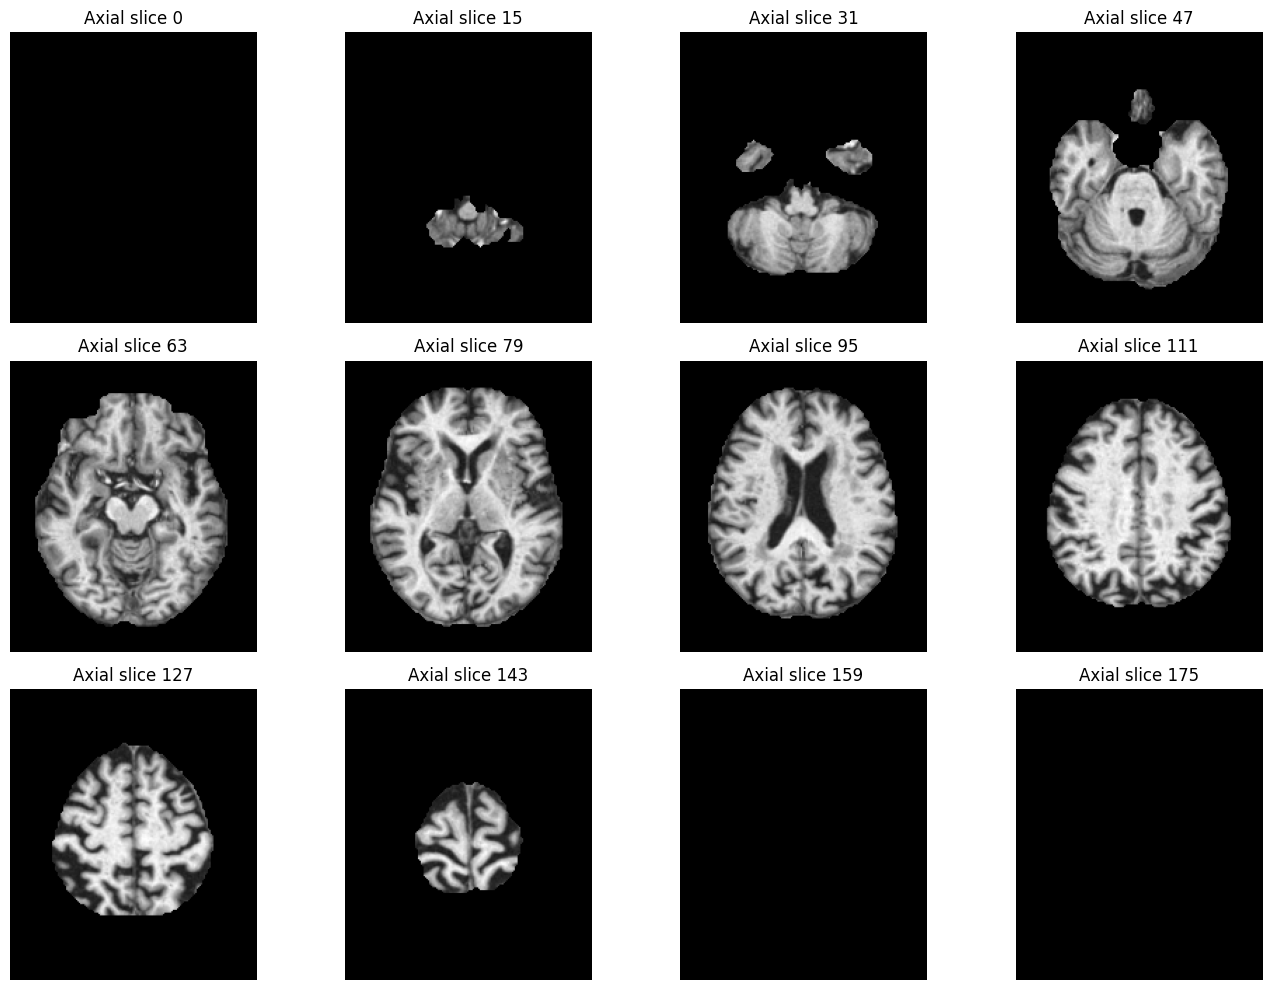

In [ ]:
# Cargar y visualizar un volumen de ejemplo

sample_row = binary_df[binary_df["split"] == "train"].iloc[0]

img = nib.load(sample_row["nii_path"])
volume = img.get_fdata()

# Quitar dimensión extra si existe
volume = np.squeeze(volume)

print("ID:", sample_row["ID"])
print("Label:", sample_row["label"])
print("CDR:", sample_row["CDR"])
print("Path:", sample_row["nii_path"])
print("Shape del volumen:", volume.shape)
print("Rango de intensidades:", volume.min(), volume.max())

# Visualizar slices axiales
slice_indices = np.linspace(0, volume.shape[2] - 1, 12, dtype=int)

plt.figure(figsize=(14, 10))

for i, idx in enumerate(slice_indices):
    plt.subplot(3, 4, i + 1)
    plt.imshow(volume[:, :, idx].T, cmap="gray", origin="lower")
    plt.title(f"Axial slice {idx}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Sección 4 - Preprocesamiento y extracción de slices 2D reales


In [ ]:
# Configuración de tamaños

IMAGE_SIZE = 128


SLICE_INDICES = list(range(50, 100, 5))

print("Slices seleccionados:", SLICE_INDICES)
print("Tamaño para GAN:", IMAGE_SIZE)

Slices seleccionados: [50, 55, 60, 65, 70, 75, 80, 85, 90, 95]
Tamaño para GAN: 128


In [ ]:
# Funciones para cargar volumen y extraer slices axiales

def load_volume(path):
    img = nib.load(path)
    volume = img.get_fdata()
    volume = np.squeeze(volume)
    return volume


def normalize_volume_zscore(volume):
    """
    Z-score normalización sobre el tejido del volumen 3D completo.
    Solo se computa la media y std sobre vóxeles con intensidad > 0 (tejido).
    Esto preserva la escala anatómica relativa entre cortes.
    """
    volume = volume.astype(np.float32)
    tissue_mask = volume > 0
    if tissue_mask.sum() == 0:
        return np.zeros_like(volume, dtype=np.float32)
    mean_val = volume[tissue_mask].mean()
    std_val = volume[tissue_mask].std()
    if std_val < 1e-6:
        return np.zeros_like(volume, dtype=np.float32)
    normalized = (volume - mean_val) / std_val
    return normalized


def extract_axial_slice(volume_normalized, slice_idx, image_size=128):
    """
    Extrae un corte axial del volumen YA normalizado por Z-score.
    """
    slice_2d = volume_normalized[:, :, slice_idx]

    # Orientación igual a la visualización
    slice_2d = slice_2d.T.astype(np.float32)

    # Redimensionar
    zoom_factors = (
        image_size / slice_2d.shape[0],
        image_size / slice_2d.shape[1]
    )
    slice_2d = zoom(slice_2d, zoom_factors, order=1)

    return slice_2d

ID: OAS1_0033_MR1
Label: sano
Shape volumen: (176, 208, 176)
Rango Z-score (tejido): -2.46 – 5.48


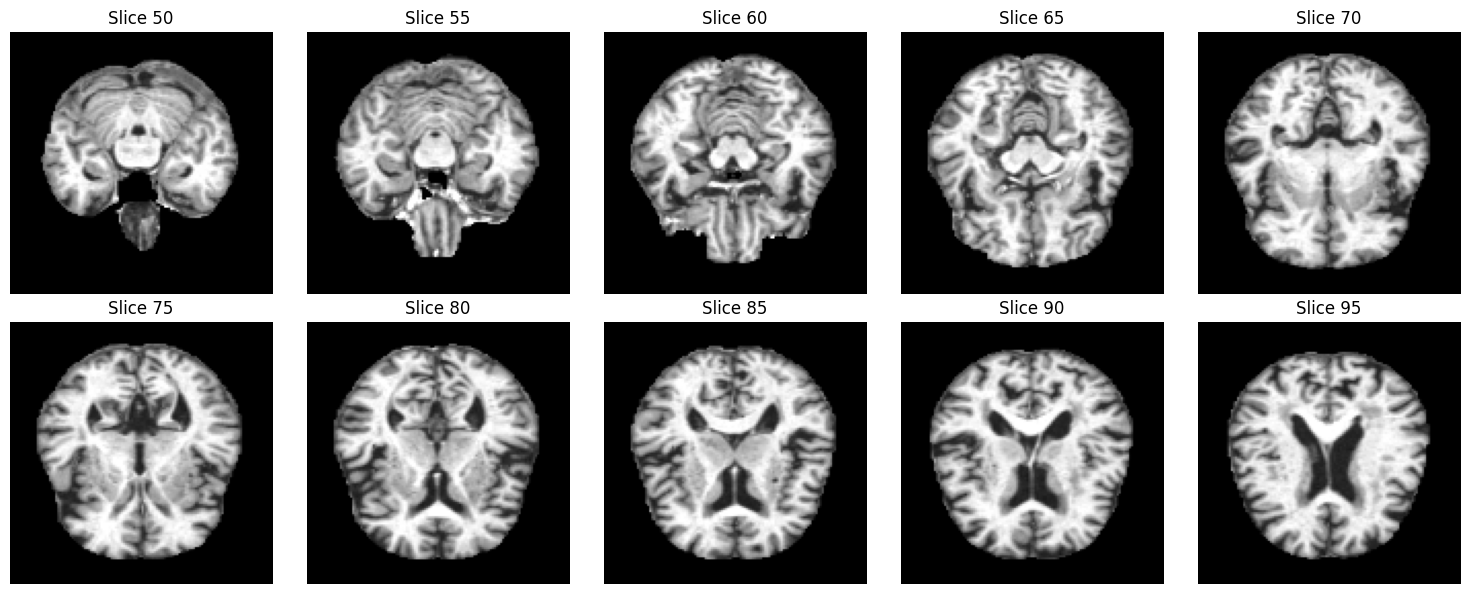

In [ ]:
# Probar extracción de los slices seleccionados

sample_row = binary_df[binary_df['split'] == 'train'].iloc[0]
volume_raw = load_volume(sample_row['nii_path'])
volume_norm = normalize_volume_zscore(volume_raw)  # normalizar antes de extraer

print('ID:', sample_row['ID'])
print('Label:', sample_row['label'])
print('Shape volumen:', volume_raw.shape)
print(f'Rango Z-score (tejido): {volume_norm[volume_norm != 0].min():.2f} – {volume_norm[volume_norm != 0].max():.2f}')

plt.figure(figsize=(15, 6))

for i, idx in enumerate(SLICE_INDICES):
    slice_2d = extract_axial_slice(
        volume_normalized=volume_norm,
        slice_idx=idx,
        image_size=IMAGE_SIZE
    )

    # percentil 1-99
    p1, p99 = np.percentile(slice_2d, [1, 99])
    slice_clipped = np.clip(slice_2d, p1, p99)
    slice_01 = (slice_clipped - p1) / (p99 - p1) if p99 > p1 else np.zeros_like(slice_clipped)

    plt.subplot(2, 5, i + 1)
    plt.imshow(slice_01, cmap='gray')
    plt.title(f'Slice {idx}')
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Crear estructura de carpetas para slices 2D reales

CLASS_NAMES = ["sano", "vmd"]
OUTPUT_ROOT = "/content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices"

REAL_SLICES_ROOT = os.path.join(OUTPUT_ROOT, "real_128")

for split in ["train", "val", "test"]:
    for label in CLASS_NAMES:
        os.makedirs(os.path.join(REAL_SLICES_ROOT, split, label), exist_ok=True)

print("Carpetas creadas en:")
print(REAL_SLICES_ROOT)

Carpetas creadas en:
/content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/real_128


In [ ]:
# Guardar un slice como PNG

def save_slice_png(slice_2d, output_path):
    """
    slice_2d debe estar normalizado en [0, 1].
    """
    slice_uint8 = (slice_2d * 255).clip(0, 255).astype(np.uint8)
    img = Image.fromarray(slice_uint8, mode="L")
    img.save(output_path)

In [ ]:
# Extraer y guardar slices reales 2D

records = []

for _, row in binary_df.iterrows():
    subject_id = row["ID"]
    label = row["label"]
    label_idx = row["label_idx"]
    split = row["split"]
    nii_path = row["nii_path"]

    # Cargar y normalizar el volumen completo antes de extraer cortes
    volume_raw = load_volume(nii_path)
    volume_norm = normalize_volume_zscore(volume_raw)

    for slice_idx in SLICE_INDICES:
        slice_2d = extract_axial_slice(
            volume_normalized=volume_norm,
            slice_idx=slice_idx,
            image_size=IMAGE_SIZE
        )

        # Guardar como PNG
        p1, p99 = np.percentile(slice_2d, [1, 99])
        slice_clipped = np.clip(slice_2d, p1, p99)
        if p99 > p1:
            slice_01 = (slice_clipped - p1) / (p99 - p1)
        else:
            slice_01 = np.zeros_like(slice_clipped)

        filename = f"{subject_id}_slice{slice_idx:03d}.png"
        output_path = os.path.join(
            REAL_SLICES_ROOT,
            split,
            label,
            filename
        )

        save_slice_png(slice_01, output_path)

        records.append({
            "subject_base": row["subject_base"],
            "ID": subject_id,
            "CDR": row["CDR"],
            "label": label,
            "label_idx": label_idx,
            "split": split,
            "slice_idx": slice_idx,
            "image_path": output_path,
            "source": "real"
        })

slices_df = pd.DataFrame(records)

print("Slices guardados:", len(slices_df))
display(slices_df.head())

print("\nDistribución de slices por split y clase:")
display(pd.crosstab(slices_df["split"], slices_df["label"], margins=True))

Slices guardados: 2050


,subject_base,ID,CDR,label,label_idx,split,slice_idx,image_path,source
0,OAS1_0033,OAS1_0033_MR1,0.0,sano,0,train,50,/content/drive/MyDrive/Proyecto imagenes y vis...,real
1,OAS1_0033,OAS1_0033_MR1,0.0,sano,0,train,55,/content/drive/MyDrive/Proyecto imagenes y vis...,real
2,OAS1_0033,OAS1_0033_MR1,0.0,sano,0,train,60,/content/drive/MyDrive/Proyecto imagenes y vis...,real
3,OAS1_0033,OAS1_0033_MR1,0.0,sano,0,train,65,/content/drive/MyDrive/Proyecto imagenes y vis...,real
4,OAS1_0033,OAS1_0033_MR1,0.0,sano,0,train,70,/content/drive/MyDrive/Proyecto imagenes y vis...,real



Distribución de slices por split y clase:


label,sano,vmd,All
split,,,
test,210,100,310
train,940,490,1430
val,200,110,310
All,1350,700,2050


In [ ]:
# Guardar índice de slices reales

SLICES_CSV_PATH = os.path.join(OUTPUT_ROOT, "slices_real_128_index.csv")

slices_df.to_csv(SLICES_CSV_PATH, index=False)

print("Índice guardado en:")
print(SLICES_CSV_PATH)

Índice guardado en:
/content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/slices_real_128_index.csv


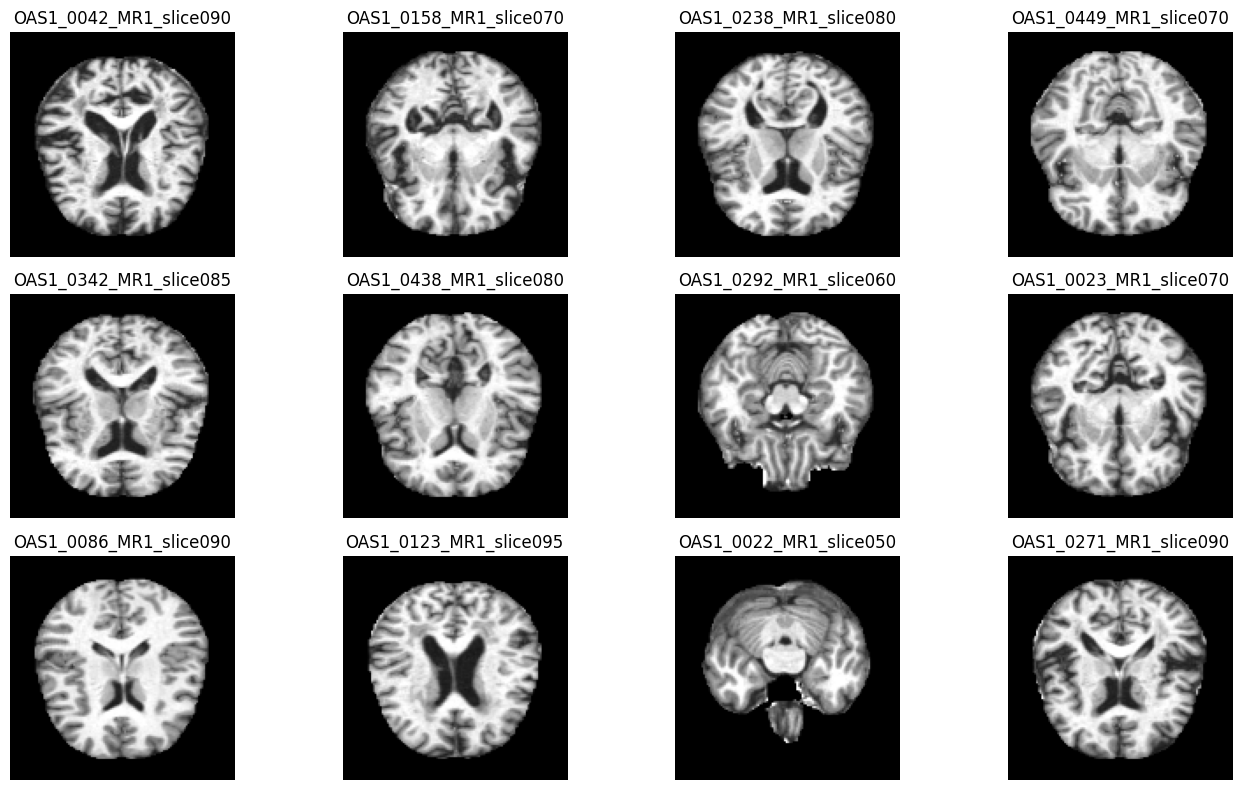

In [ ]:
# Visualizar algunos slices

sample_paths = slices_df.sample(12, random_state=RANDOM_SEED)["image_path"].tolist()

plt.figure(figsize=(14, 8))

for i, path in enumerate(sample_paths):
    img = Image.open(path).convert("L")

    plt.subplot(3, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(os.path.basename(path).replace(".png", ""))
    plt.axis("off")

plt.tight_layout()
plt.show()

## Sección 5 - Preparación del dataset para entrenamiento del GAN

In [ ]:
# Dataframe para entrenamiento del GAN (SOLO TRAIN)

gan_train_df = slices_df[slices_df["split"] == "train"].copy()

print("Slices para entrenar GAN:", len(gan_train_df))

print("\nDistribución GAN train:")
display(pd.crosstab(gan_train_df["label"], gan_train_df["source"], margins=True))

print("\nDistribución por clase:")
display(gan_train_df["label"].value_counts())

Slices para entrenar GAN: 1430

Distribución GAN train:


source,real,All
label,,
sano,940,940
vmd,490,490
All,1430,1430



Distribución por clase:


,count
label,
sano,940
vmd,490


In [ ]:
# Dataset para entrenamiento del GAN

class GANSlicesDataset(Dataset):
    def __init__(self, dataframe, image_size=128):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_size = image_size

        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])  # [0,1] -> [-1,1]
        ])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "image_path"]
        image = Image.open(image_path).convert("L")
        image = self.transform(image)
        return image

In [ ]:
# DataLoader del GAN para clase VMD

gan_label = "vmd"

gan_vmd_df = gan_train_df[gan_train_df["label"] == gan_label].copy()

BATCH_SIZE_GAN = 32

gan_vmd_dataset = GANSlicesDataset(
    dataframe=gan_vmd_df,
    image_size=IMAGE_SIZE
)

gan_vmd_loader = DataLoader(
    gan_vmd_dataset,
    batch_size=BATCH_SIZE_GAN,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Clase GAN:", gan_label)
print("Imágenes reales para entrenar GAN:", len(gan_vmd_dataset))
print("Batch size:", BATCH_SIZE_GAN)

batch = next(iter(gan_vmd_loader))
print("Shape de un batch:", batch.shape)
print("Rango del batch:", batch.min().item(), batch.max().item())

Clase GAN: vmd
Imágenes reales para entrenar GAN: 490
Batch size: 32
Shape de un batch: torch.Size([32, 1, 128, 128])
Rango del batch: -1.0 1.0


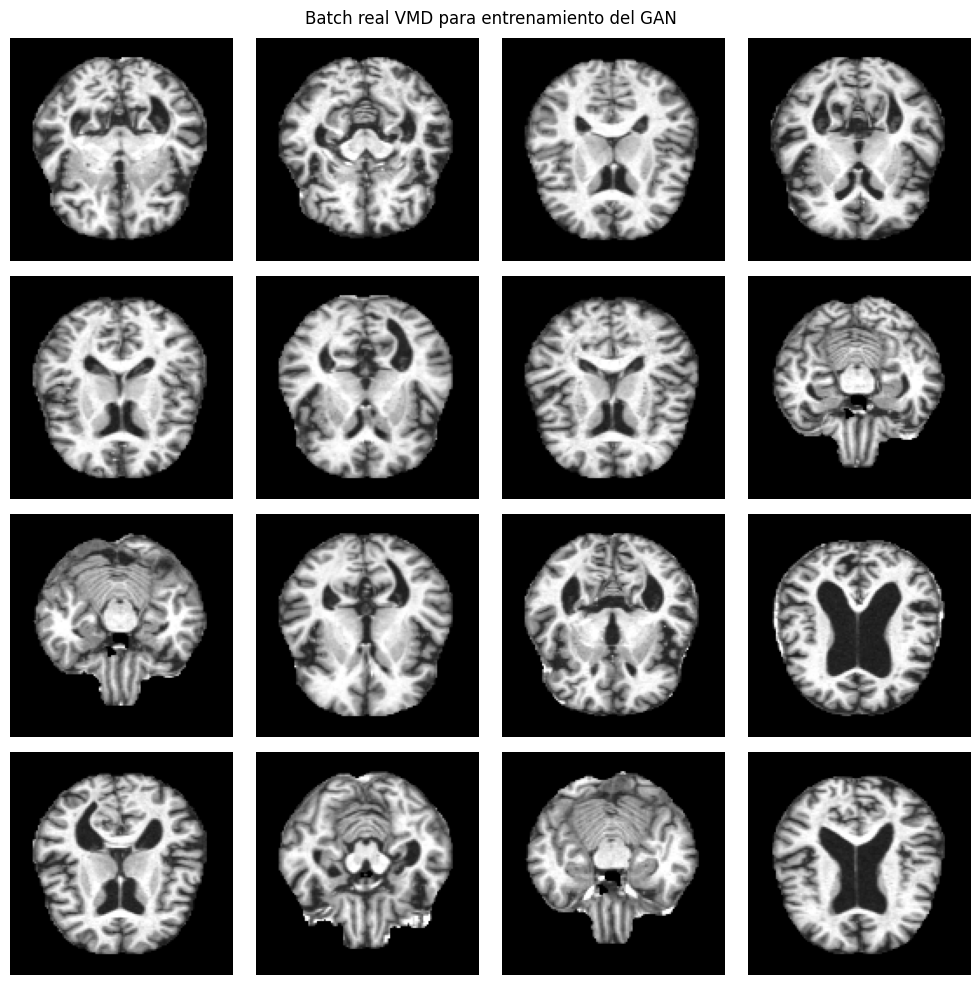

In [ ]:
# Visualizar imágenes reales usadas para entrenar el GAN

real_batch = next(iter(gan_vmd_loader))

plt.figure(figsize=(10, 10))

for i in range(16):
    img = real_batch[i].squeeze().cpu().numpy()
    img = (img + 1) / 2  # [-1,1] -> [0,1]

    plt.subplot(4, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")

plt.suptitle("Batch real VMD para entrenamiento del GAN")
plt.tight_layout()
plt.show()

## Sección 6 - Definición y entrenamiento del DCGAN

In [ ]:
# Arquitectura DCGAN

LATENT_DIM = 100
IMG_CHANNELS = 1
FEATURES_G = 64
FEATURES_D = 64


class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_channels=1, features_g=64):
        super().__init__()
        self.net = nn.Sequential(
            # Entrada: latent_dim × 1 × 1
            nn.ConvTranspose2d(latent_dim, features_g * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features_g * 16),
            nn.ReLU(True),
            # → features_g*16 × 4 × 4

            nn.ConvTranspose2d(features_g * 16, features_g * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),
            # → features_g*8 × 8 × 8

            nn.ConvTranspose2d(features_g * 8, features_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),
            # → features_g*4 × 16 × 16

            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),
            # → features_g*2 × 32 × 32

            nn.ConvTranspose2d(features_g * 2, features_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),
            # → features_g × 64 × 64

            nn.ConvTranspose2d(features_g, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
            # → img_channels × 128 × 128
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, img_channels=1, features_d=64):
        super().__init__()
        self.net = nn.Sequential(
            # Entrada: img_channels × 128 × 128
            nn.Conv2d(img_channels, features_d, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # → features_d × 64 × 64

            nn.Conv2d(features_d, features_d * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # → features_d*2 × 32 × 32

            nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # → features_d*4 × 16 × 16

            nn.Conv2d(features_d * 4, features_d * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # → features_d*8 × 8 × 8

            nn.Conv2d(features_d * 8, features_d * 16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 16),
            nn.LeakyReLU(0.2, inplace=True),
            # → features_d*16 × 4 × 4

            # Sin Sigmoid: BCEWithLogitsLoss lo incorpora internamente
            nn.Conv2d(features_d * 16, 1, 4, 1, 0, bias=False)
            # → 1 × 1 × 1
        )

    def forward(self, x):
        return self.net(x).view(-1)


In [ ]:
# Inicialización de pesos, instanciación y verificación de dimensiones

def weights_init_dcgan(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


G_vmd = Generator(
    latent_dim=LATENT_DIM,
    img_channels=IMG_CHANNELS,
    features_g=FEATURES_G
).to(device)

D_vmd = Discriminator(
    img_channels=IMG_CHANNELS,
    features_d=FEATURES_D
).to(device)

G_vmd.apply(weights_init_dcgan)
D_vmd.apply(weights_init_dcgan)

# Verificar dimensiones
z_test = torch.randn(4, LATENT_DIM, 1, 1, device=device)
fake_test = G_vmd(z_test)
disc_test = D_vmd(fake_test)
print('Generator output shape    :', fake_test.shape)
print('Discriminator output shape:', disc_test.shape)
print('Fake images range         :', fake_test.min().item(), '–', fake_test.max().item())
print('Modelos inicializados correctamente.')


Generator output shape    : torch.Size([4, 1, 128, 128])
Discriminator output shape: torch.Size([4])
Fake images range         : -0.7932462096214294 – 0.7763682007789612
Modelos inicializados correctamente.


In [ ]:
# Configuración de entrenamiento GAN

LR_G = 0.0002
LR_D = 0.00005

BETA1 = 0.5
BETA2 = 0.999

NUM_EPOCHS_GAN = 150

criterion = nn.BCEWithLogitsLoss()

optimizer_G_vmd = optim.Adam(
    G_vmd.parameters(),
    lr=LR_G,
    betas=(BETA1, BETA2)
)

optimizer_D_vmd = optim.Adam(
    D_vmd.parameters(),
    lr=LR_D,
    betas=(BETA1, BETA2)
)

fixed_noise = torch.randn(16, LATENT_DIM, 1, 1, device=device)

print(f'Configuración lista. LR_G={LR_G} | LR_D={LR_D} | Epochs={NUM_EPOCHS_GAN}')
print(f'Criterion: {criterion.__class__.__name__}')


# Función para visualizar imágenes generadas durante el entrenamiento
def show_generated_images(generator, noise, title='Imágenes generadas'):
    generator.eval()
    try:
        with torch.no_grad():
            fake_images = generator(noise).detach().cpu()
        fake_images = (fake_images + 1) / 2  # [-1,1] -> [0,1]
        plt.figure(figsize=(8, 8))
        for i in range(min(16, fake_images.size(0))):
            img = fake_images[i].squeeze().numpy()
            plt.subplot(4, 4, i + 1)
            plt.imshow(img, cmap='gray')
            plt.axis('off')
        plt.suptitle(title)
        plt.tight_layout()
        plt.show()
    finally:
        generator.train()


Configuración lista. LR_G=0.0002 | LR_D=5e-05 | Epochs=150
Criterion: BCEWithLogitsLoss


In [ ]:
# Entrenamiento DCGAN VMD

G_losses_vmd = []
D_losses_vmd = []

for epoch in range(NUM_EPOCHS_GAN):
    for real_images in gan_vmd_loader:
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Label smoothing para el discriminador (etiquetas reales)
        real_labels = torch.full((batch_size,), 0.9, device=device)
        fake_labels = torch.full((batch_size,), 0.1, device=device)

        # Ruido decreciente en imágenes reales para estabilizar D
        noise_std = max(0.05 * (1 - epoch / NUM_EPOCHS_GAN), 0.0)
        real_images_noisy = real_images + noise_std * torch.randn_like(real_images)
        real_images_noisy = torch.clamp(real_images_noisy, -1, 1)

        # -------------------------
        # 1. Entrenar Discriminator
        # -------------------------
        D_vmd.zero_grad()

        outputs_real = D_vmd(real_images_noisy)
        loss_D_real = criterion(outputs_real, real_labels)

        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake_images = G_vmd(noise)

        fake_images_noisy = fake_images.detach() + noise_std * torch.randn_like(fake_images)
        fake_images_noisy = torch.clamp(fake_images_noisy, -1, 1)

        outputs_fake = D_vmd(fake_images_noisy)
        loss_D_fake = criterion(outputs_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optimizer_D_vmd.step()

        # -------------------------
        # 2. Entrenar Generator
        # -------------------------
        G_vmd.zero_grad()

        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake_images = G_vmd(noise)

        outputs_fake_for_G = D_vmd(fake_images)

        target_for_G = torch.ones(batch_size, device=device)

        loss_G = criterion(outputs_fake_for_G, target_for_G)
        loss_G.backward()
        optimizer_G_vmd.step()

    G_losses_vmd.append(loss_G.item())
    D_losses_vmd.append(loss_D.item())

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch+1}/{NUM_EPOCHS_GAN}] "
            f"Loss_D: {loss_D.item():.4f} "
            f"Loss_G: {loss_G.item():.4f}"
        )
        show_generated_images(
            G_vmd,
            fixed_noise,
            title=f"VMD generado - Epoch {epoch+1}"
        )

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Guardar checkpoint del GAN VMD actual

CHECKPOINT_DIR = os.path.join(OUTPUT_ROOT, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

checkpoint_path = os.path.join(CHECKPOINT_DIR, "dcgan_vmd_128_current.pth")

torch.save({
    "G_state_dict": G_vmd.state_dict(),
    "D_state_dict": D_vmd.state_dict(),
    "optimizer_G_state_dict": optimizer_G_vmd.state_dict(),
    "optimizer_D_state_dict": optimizer_D_vmd.state_dict(),
    "G_losses": G_losses_vmd,
    "D_losses": D_losses_vmd,
    "latent_dim": LATENT_DIM,
    "image_size": IMAGE_SIZE,
    "features_g": FEATURES_G,
    "features_d": FEATURES_D,
}, checkpoint_path)

print("Checkpoint guardado en:")
print(checkpoint_path)

Checkpoint guardado en:
/content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/checkpoints/dcgan_vmd_128_current.pth


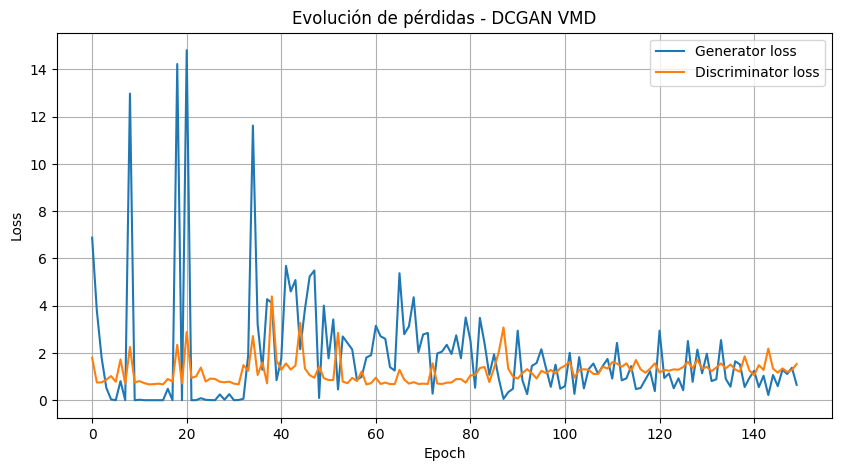

In [ ]:
# Pérdidas del GAN

plt.figure(figsize=(10, 5))
plt.plot(G_losses_vmd, label="Generator loss")
plt.plot(D_losses_vmd, label="Discriminator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución de pérdidas - DCGAN VMD")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Continuación de entrenamiento con learning rates más suaves

for param_group in optimizer_G_vmd.param_groups:
    param_group["lr"] = 0.0001

for param_group in optimizer_D_vmd.param_groups:
    param_group["lr"] = 0.00003

EXTRA_EPOCHS_GAN = 100

print("LR_G actual:", optimizer_G_vmd.param_groups[0]["lr"])
print("LR_D actual:", optimizer_D_vmd.param_groups[0]["lr"])
print("Epochs extra:", EXTRA_EPOCHS_GAN)

LR_G actual: 0.0001
LR_D actual: 3e-05
Epochs extra: 100


In [ ]:
# Fine-tuning del DCGAN VMD

start_epoch = len(G_losses_vmd)

for epoch in range(EXTRA_EPOCHS_GAN):
    global_epoch = start_epoch + epoch + 1

    for real_images in gan_vmd_loader:
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Label smoothing para el discriminador
        real_labels = torch.full((batch_size,), 0.9, device=device)
        fake_labels = torch.full((batch_size,), 0.1, device=device)

        noise_std = max(0.03 * (1 - epoch / EXTRA_EPOCHS_GAN), 0.0)

        real_images_noisy = real_images + noise_std * torch.randn_like(real_images)
        real_images_noisy = torch.clamp(real_images_noisy, -1, 1)

        # Entrenar D
        D_vmd.zero_grad()

        outputs_real = D_vmd(real_images_noisy)
        loss_D_real = criterion(outputs_real, real_labels)

        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake_images = G_vmd(noise)

        fake_images_noisy = fake_images.detach() + noise_std * torch.randn_like(fake_images)
        fake_images_noisy = torch.clamp(fake_images_noisy, -1, 1)

        outputs_fake = D_vmd(fake_images_noisy)
        loss_D_fake = criterion(outputs_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optimizer_D_vmd.step()

        # Entrenar G
        G_vmd.zero_grad()

        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake_images = G_vmd(noise)

        outputs_fake_for_G = D_vmd(fake_images)

        target_for_G = torch.ones(batch_size, device=device)

        loss_G = criterion(outputs_fake_for_G, target_for_G)
        loss_G.backward()
        optimizer_G_vmd.step()

    G_losses_vmd.append(loss_G.item())
    D_losses_vmd.append(loss_D.item())

    if global_epoch % 10 == 0:
        print(
            f"Epoch total [{global_epoch}] "
            f"Loss_D: {loss_D.item():.4f} "
            f"Loss_G: {loss_G.item():.4f}"
        )
        show_generated_images(
            G_vmd,
            fixed_noise,
            title=f"VMD generado - Epoch total {global_epoch}"
        )

Output hidden; open in https://colab.research.google.com to view.

## Sección 7 - Evaluación de calidad y generación sintética


In [ ]:
# Generación de imágenes sintéticas temporales para evaluar calidad

N_EVAL = min(256, len(gan_vmd_dataset))

G_vmd.eval()

with torch.no_grad():
    noise = torch.randn(N_EVAL, LATENT_DIM, 1, 1, device=device)
    synth_eval = G_vmd(noise).cpu()

G_vmd.train()

synth_eval_01 = (synth_eval + 1) / 2
synth_eval_01 = synth_eval_01.clamp(0, 1)

print("Sintéticas eval shape:", synth_eval_01.shape)
print("Rango:", synth_eval_01.min().item(), synth_eval_01.max().item())

Sintéticas eval shape: torch.Size([256, 1, 128, 128])
Rango: 2.384185791015625e-07 0.9999138116836548


In [ ]:
# Carga de imágenes reales VMD de train para comparar

real_eval_list = []

for i in range(N_EVAL):
    img = gan_vmd_dataset[i]
    real_eval_list.append(img)

real_eval = torch.stack(real_eval_list, dim=0)

real_eval_01 = (real_eval + 1) / 2
real_eval_01 = real_eval_01.clamp(0, 1)

print("Reales eval shape:", real_eval_01.shape)
print("Rango:", real_eval_01.min().item(), real_eval_01.max().item())

Reales eval shape: torch.Size([256, 1, 128, 128])
Rango: 0.0 1.0


In [ ]:
# Diversidad mediante SSIM promedio

try:
    from skimage.metrics import structural_similarity as ssim

    def mean_pairwise_ssim(images, max_pairs=1000):
        """
        images: tensor [N, 1, H, W] en [0, 1]
        """
        imgs = images.squeeze(1).numpy()
        n = imgs.shape[0]

        scores = []
        rng = np.random.default_rng(RANDOM_SEED)

        for _ in range(max_pairs):
            i, j = rng.choice(n, size=2, replace=False)
            score = ssim(imgs[i], imgs[j], data_range=1.0)
            scores.append(score)

        return float(np.mean(scores)), float(np.std(scores))

    synth_ssim_mean, synth_ssim_std = mean_pairwise_ssim(synth_eval_01)
    real_ssim_mean, real_ssim_std = mean_pairwise_ssim(real_eval_01)

    print("SSIM promedio entre reales VMD:")
    print(f"{real_ssim_mean:.4f} ± {real_ssim_std:.4f}")

    print("\nSSIM promedio entre sintéticas VMD:")
    print(f"{synth_ssim_mean:.4f} ± {synth_ssim_std:.4f}")



SSIM promedio entre reales VMD:
0.4903 ± 0.0776

SSIM promedio entre sintéticas VMD:
0.5887 ± 0.1836


## Sección 8 - Construcción del dataset aumentado final

In [ ]:
# Guardar checkpoint final del GAN VMD

final_checkpoint_path = os.path.join(CHECKPOINT_DIR, "dcgan_vmd_128_final.pth")

torch.save({
    "G_state_dict": G_vmd.state_dict(),
    "D_state_dict": D_vmd.state_dict(),
    "optimizer_G_state_dict": optimizer_G_vmd.state_dict(),
    "optimizer_D_state_dict": optimizer_D_vmd.state_dict(),
    "G_losses": G_losses_vmd,
    "D_losses": D_losses_vmd,
    "latent_dim": LATENT_DIM,
    "image_size": IMAGE_SIZE,
    "features_g": FEATURES_G,
    "features_d": FEATURES_D,
}, final_checkpoint_path)

print("Checkpoint final guardado en:")
print(final_checkpoint_path)

Checkpoint final guardado en:
/content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/checkpoints/dcgan_vmd_128_final.pth


In [ ]:
# Generar imágenes sintéticas VMD

from skimage.metrics import structural_similarity as ssim

# Fallback
if "NUM_SYNTH_VMD" not in globals():
    train_slices_local = slices_df[slices_df["split"] == "train"]
    n_sano_local       = (train_slices_local["label"] == "sano").sum()
    n_vmd_real_local   = (train_slices_local["label"] == "vmd").sum()
    NUM_SYNTH_VMD      = max(0, n_sano_local - n_vmd_real_local)
    print(f"NUM_SYNTH_VMD: {NUM_SYNTH_VMD}")

OVERSAMPLE_FACTOR     = 12
SIM_DIVERSITY_THRESH = 0.95
TISSUE_THRESHOLD      = 0.02
TISSUE_PIXEL_MIN      = 0.03

_real_ssim_mean_ref = globals().get("real_ssim_mean", float("nan"))

SYNTH_SLICES_ROOT = os.path.join(OUTPUT_ROOT, "synthetic_128")
SYNTH_VMD_DIR     = os.path.join(SYNTH_SLICES_ROOT, "train", "vmd")
os.makedirs(SYNTH_VMD_DIR, exist_ok=True)

G_vmd.eval()

synthetic_records = []
accepted_imgs     = []
generated_count   = 0
attempted_count   = 0
rejected_tissue   = 0
rejected_ssim     = 0

batch_size_gen = 64
max_pool_size  = NUM_SYNTH_VMD * OVERSAMPLE_FACTOR
SSIM_COMPARE_K = 20

import random as _random
_rng = _random.Random(RANDOM_SEED)

with torch.no_grad():
    while generated_count < NUM_SYNTH_VMD and attempted_count < max_pool_size:
        current_batch_size = min(batch_size_gen, max_pool_size - attempted_count)
        if current_batch_size <= 0:
            break

        noise = torch.randn(current_batch_size, LATENT_DIM, 1, 1, device=device)
        fake_images = G_vmd(noise)

        fake_images_01 = (fake_images + 1) / 2
        fake_images_01 = fake_images_01.clamp(0, 1)

        for i in range(current_batch_size):
            if generated_count >= NUM_SYNTH_VMD:
                break

            attempted_count += 1
            img_array = fake_images_01[i].squeeze().cpu().numpy()

            # Filtro 1: tejido mínimo
            tissue_fraction = (img_array > TISSUE_PIXEL_MIN).mean()
            if tissue_fraction < TISSUE_THRESHOLD:
                rejected_tissue += 1
                continue

            # Filtro 2: diversidad SSIM
            if len(accepted_imgs) >= 1:
                k = min(SSIM_COMPARE_K, len(accepted_imgs))
                sample = _rng.sample(accepted_imgs, k)
                max_ssim = max(ssim(img_array, ref, data_range=1.0) for ref in sample)
                if max_ssim >= SIM_DIVERSITY_THRESH:
                    rejected_ssim += 1
                    continue

            img_uint8 = (img_array * 255).astype(np.uint8)
            filename  = f"synthetic_vmd_{generated_count:04d}.png"
            output_path = os.path.join(SYNTH_VMD_DIR, filename)
            Image.fromarray(img_uint8, mode="L").save(output_path)

            synthetic_records.append({
                "subject_base": f"synthetic_vmd_{generated_count:04d}",
                "ID":           f"synthetic_vmd_{generated_count:04d}",
                "CDR":          0.5,
                "label":        "vmd",
                "label_idx":    1,
                "split":        "train",
                "slice_idx":    -1,
                "image_path":   output_path,
                "source":       "synthetic_dcgan"
            })
            accepted_imgs.append(img_array)
            generated_count += 1

G_vmd.train()

synthetic_vmd_df = pd.DataFrame(synthetic_records)

print(f"Imágenes intentadas       : {attempted_count}")
print(f"Rechazadas por tejido (<{TISSUE_THRESHOLD*100:.0f}%): {rejected_tissue} "
      f"({100*rejected_tissue/max(attempted_count,1):.1f}%)")
print(f"Rechazadas por SSIM ≥{SIM_DIVERSITY_THRESH}: {rejected_ssim} "
      f"({100*rejected_ssim/max(attempted_count,1):.1f}%)")
print(f"Imágenes aceptadas        : {generated_count} / {NUM_SYNTH_VMD}")

if generated_count < NUM_SYNTH_VMD:
    print(f"\n ADVERTENCIA: solo se aceptaron {generated_count} de {NUM_SYNTH_VMD} necesarias.")

if generated_count >= 2:
    sample_pairs = min(500, generated_count * (generated_count - 1) // 2)
    scores = []
    for _ in range(sample_pairs):
        i, j = _rng.sample(range(generated_count), 2)
        scores.append(ssim(accepted_imgs[i], accepted_imgs[j], data_range=1.0))
    print(f"\nSSIM pool aceptado: {np.mean(scores):.4f} ± {np.std(scores):.4f}")
    print(f"(Recuerda: SSIM reales VMD ≈ {_real_ssim_mean_ref:.4f} — objetivo: pool ≤ reales)")

display(synthetic_vmd_df.head())

Imágenes intentadas       : 1286
Rechazadas por tejido (<2%): 0 (0.0%)
Rechazadas por SSIM ≥0.95: 836 (65.0%)
Imágenes aceptadas        : 450 / 450

SSIM pool aceptado: 0.5874 ± 0.1760
(Recuerda: SSIM reales VMD ≈ 0.4903 — objetivo: pool ≤ reales)


,subject_base,ID,CDR,label,label_idx,split,slice_idx,image_path,source
0,synthetic_vmd_0000,synthetic_vmd_0000,0.5,vmd,1,train,-1,/content/drive/MyDrive/Proyecto imagenes y vis...,synthetic_dcgan
1,synthetic_vmd_0001,synthetic_vmd_0001,0.5,vmd,1,train,-1,/content/drive/MyDrive/Proyecto imagenes y vis...,synthetic_dcgan
2,synthetic_vmd_0002,synthetic_vmd_0002,0.5,vmd,1,train,-1,/content/drive/MyDrive/Proyecto imagenes y vis...,synthetic_dcgan
3,synthetic_vmd_0003,synthetic_vmd_0003,0.5,vmd,1,train,-1,/content/drive/MyDrive/Proyecto imagenes y vis...,synthetic_dcgan
4,synthetic_vmd_0004,synthetic_vmd_0004,0.5,vmd,1,train,-1,/content/drive/MyDrive/Proyecto imagenes y vis...,synthetic_dcgan


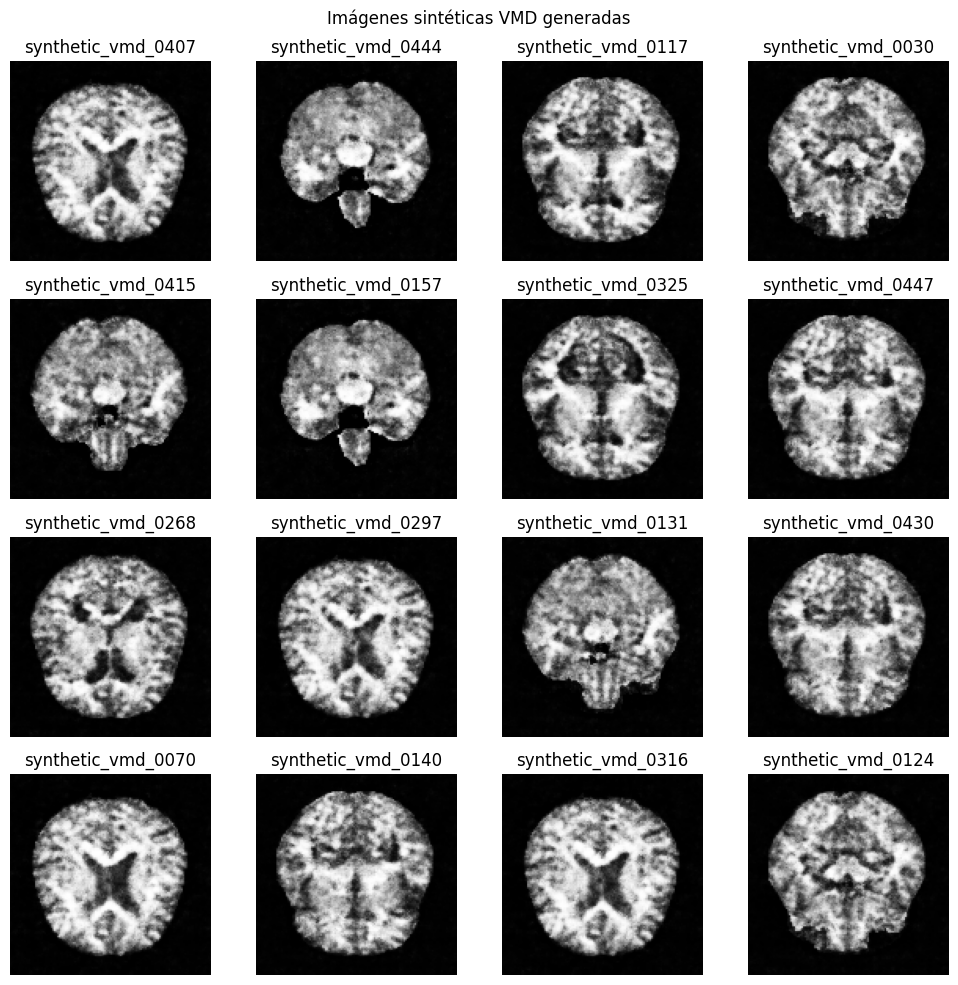

In [ ]:
# Visualizar sintéticas VMD generadas desde disco

sample_synth_paths = synthetic_vmd_df.sample(
    min(16, len(synthetic_vmd_df)),
    random_state=RANDOM_SEED
)["image_path"].tolist()

plt.figure(figsize=(10, 10))

for i, path in enumerate(sample_synth_paths):
    img = Image.open(path).convert("L")

    plt.subplot(4, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(os.path.basename(path).replace(".png", ""))
    plt.axis("off")

plt.suptitle("Imágenes sintéticas VMD generadas")
plt.tight_layout()
plt.show()

In [ ]:
# Crear dataframe aumentado

augmented_slices_df = pd.concat(
    [slices_df, synthetic_vmd_df],
    ignore_index=True
)

print("Total imágenes:", len(augmented_slices_df))

print("\nDistribución por split, clase y source:")
display(
    pd.crosstab(
        [augmented_slices_df["split"], augmented_slices_df["label"]],
        augmented_slices_df["source"],
        margins=True
    )
)

print("\nDistribución final por split y clase:")
display(
    pd.crosstab(
        augmented_slices_df["split"],
        augmented_slices_df["label"],
        margins=True
    )
)

Total imágenes: 2500

Distribución por split, clase y source:


source       real  synthetic_dcgan   All
split label                             
test  sano    210                0   210
      vmd     100                0   100
train sano    940                0   940
      vmd     490              450   940
val   sano    200                0   200
      vmd     110                0   110
All          2050              450  2500


Distribución final por split y clase:


label,sano,vmd,All
split,,,
test,210,100,310
train,940,940,1880
val,200,110,310
All,1350,1150,2500


In [ ]:
# Guardar CSV aumentado

AUGMENTED_CSV_PATH = os.path.join(OUTPUT_ROOT, "slices_augmented_128_index.csv")

missing_paths = augmented_slices_df[
    ~augmented_slices_df["image_path"].apply(os.path.exists)
]

if len(missing_paths) > 0:
    print(f" ADVERTENCIA: {len(missing_paths)} paths NO existen en disco:")
    display(missing_paths[["ID", "split", "label", "source", "image_path"]].head(10))
    raise FileNotFoundError(
        f"Se encontraron {len(missing_paths)} paths inválidos. "
    )

augmented_slices_df.to_csv(AUGMENTED_CSV_PATH, index=False)

print(f"CSV validado y guardado: {len(augmented_slices_df)} registros")
print(f"   Paths verificados en disco: {len(augmented_slices_df) - len(missing_paths)}/{len(augmented_slices_df)}")
print(f"   Guardado en: {AUGMENTED_CSV_PATH}")

CSV validado y guardado: 2500 registros
   Paths verificados en disco: 2500/2500
   Guardado en: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/slices_augmented_128_index.csv


Mounted at /content/drive
Sources en el CSV: ['real', 'synthetic_dcgan']
Reales vmd/train disponibles  : 490
Sintéticas vmd/train disponibles: 450


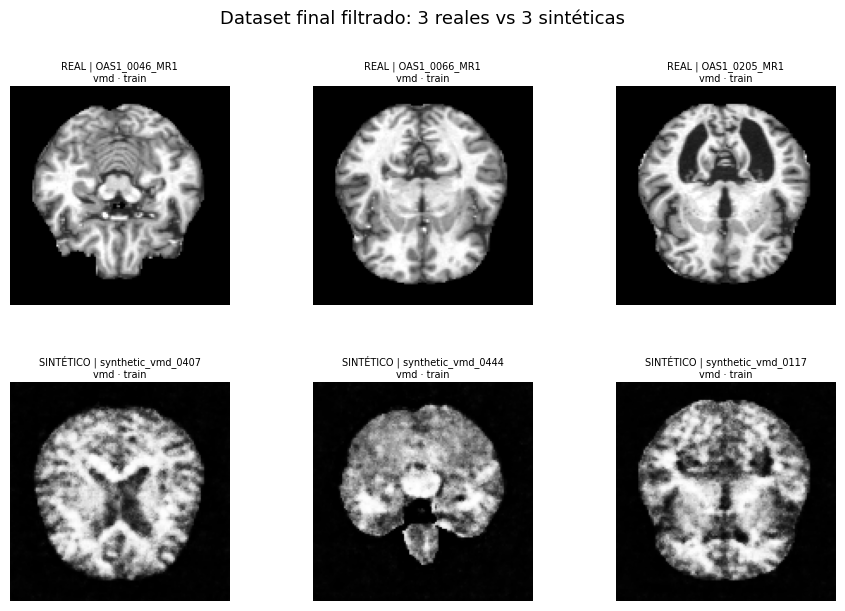

Figura guardada en: /content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices/grid_real_vs_sintetico_6.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

try:
    import google.colab
    IN_COLAB = True
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    OUTPUT_ROOT = "/content/drive/MyDrive/Proyecto imagenes y vision/OASIS_2D_Slices"
else:
    OUTPUT_ROOT = os.path.join(os.getcwd(), "OASIS_2D_Slices")

AUGMENTED_CSV_PATH = os.path.join(OUTPUT_ROOT, "slices_augmented_128_index.csv")

assert os.path.exists(AUGMENTED_CSV_PATH), f"No se encontró: {AUGMENTED_CSV_PATH}"
df = pd.read_csv(AUGMENTED_CSV_PATH)

sources = df["source"].unique().tolist()
print(f"Sources en el CSV: {sources}")

source_real  = "real"
source_synth = "synthetic_dcgan"

real_train = df[
    (df["source"] == source_real) &
    (df["split"]  == "train") &
    (df["label"]  == "vmd")
]

synth_train = df[
    (df["source"] == source_synth) &
    (df["split"]  == "train") &
    (df["label"]  == "vmd")
]

print(f"Reales vmd/train disponibles  : {len(real_train)}")
print(f"Sintéticas vmd/train disponibles: {len(synth_train)}")

assert len(real_train)  >= 3, f"No hay suficientes reales vmd/train (hay {len(real_train)})"
assert len(synth_train) >= 3, f"No hay suficientes sintéticas vmd/train (hay {len(synth_train)})"

real_train  = real_train.sample(3, random_state=42)
synth_train = synth_train.sample(3, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
fig.patch.set_facecolor("white")
fig.suptitle("Dataset final filtrado: 3 reales vs 3 sintéticas",
             color="black", fontsize=13, y=1.01)

rows = [
    (real_train,  "REAL",      0),
    (synth_train, "SINTÉTICO", 1),
]

for row_df, tag, row_idx in rows:
    for col_idx, (_, record) in enumerate(row_df.iterrows()):
        ax = axes[row_idx, col_idx]

        img_path = record["image_path"]
        if not os.path.exists(img_path):
            print(f"  ADVERTENCIA: no existe {img_path}")
            ax.text(0.5, 0.5, "No encontrada", color="red",
                    ha="center", va="center", transform=ax.transAxes)
            ax.axis("off")
            continue

        img = Image.open(img_path).convert("L")
        ax.imshow(np.array(img), cmap="gray")
        ax.axis("off")

        ax.set_title(
            f"{tag} | {record['ID']}\nvmd · train",
            color="black", fontsize=7, pad=3
        )

        color = "#4A90D9" if tag == "REAL" else "#E8A838"
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)
            spine.set_visible(True)

plt.tight_layout()
plt.subplots_adjust(wspace=0.15, hspace=0.35)
out_path = os.path.join(OUTPUT_ROOT, "grid_real_vs_sintetico_6.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Figura guardada en: {out_path}")